In [1]:
pip install wfdb pandas numpy scikit-learn matplotlib seaborn pillow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.9/163.9 kB 14.9 MB/s eta 0:00:00


In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix

# Dataset load from URL
column_names = ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'num']
df = pd.read_csv("https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data", names=column_names, na_values="?")

# Handling the missing values and setting the Target (0 = No Disease, 1 = Disease)
df = df.dropna()
df['target'] = df['num'].apply(lambda x: 1 if x > 0 else 0)

X = df.drop(columns=['num', 'target'])
y = df['target']

# Train-Test Split and Baseline Logistic Regression Model
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# Model Testing
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_prob))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.8833333333333333
ROC AUC: 0.9467592592592592
Confusion Matrix:
 [[32  4]
 [ 3 21]]


Generating record list for: 100
Generating list of all files for: 100
Created local base download directory: mitdb
Finished downloading files
Sampling Frequency: 360 Hz


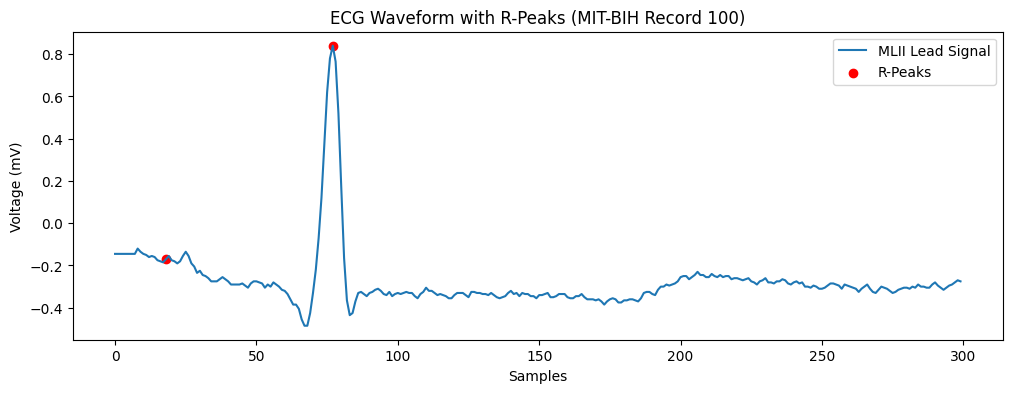

In [3]:
import wfdb
import matplotlib.pyplot as plt

# MIT-BIH database se Record 100 download and read
record_name = '100'
wfdb.dl_database('mitdb', dl_dir='mitdb', records=[record_name])

# Signals aur expert doctor annotations read karna
signal_path = f'mitdb/{record_name}'
record = wfdb.rdrecord(signal_path, sampto=1000)
annotation = wfdb.rdann(signal_path, 'atr', sampto=1000)

print("Sampling Frequency:", record.fs, "Hz")

# ECG Waveform ko Plot karna
plt.figure(figsize=(12, 4))
plt.plot(record.p_signal[:300, 0], label='MLII Lead Signal')

# Annotations (R-Peaks) highlighting
peak_indices = annotation.sample[annotation.sample < 300]
plt.scatter(peak_indices, record.p_signal[peak_indices, 0], color='red', label='R-Peaks')
plt.title("ECG Waveform with R-Peaks (MIT-BIH Record 100)")
plt.xlabel("Samples")
plt.ylabel("Voltage (mV)")
plt.legend()
plt.show()

In [4]:
from collections import Counter
import re

# Sample Clinical Text Note
clinical_note = """
Patient is a 54-year-old male presenting with acute substernal chest pain radiating to the left arm,
accompanied by diaphoresis and shortness of breath. ECG reveals ST-segment elevation.
Patient has a history of hypertension. Troponin levels are elevated.
"""

# Tokenization aur Stopwords Removal Function
def extract_clinical_keywords(text):
    # Regex se punctuation hata kar words extract karna
    words = re.findall(r'\b[a-zA-Z]{3,}\b', text.lower())
    stopwords = {'and', 'the', 'with', 'to', 'is', 'in', 'are', 'for', 'of', 'has'}
    keywords = [w for w in words if w not in stopwords]
    return keywords

tokens = extract_clinical_keywords(clinical_note)
word_counts = Counter(tokens)

print("Top Clinical Keywords:")
for word, freq in word_counts.most_common(5):
    print(f"- {word}: {freq}")

Top Clinical Keywords:
- patient: 2
- year: 1
- old: 1
- male: 1
- presenting: 1


Original Image Format/Size: (640, 427)
Preprocessed Tensor Shape: (224, 224)
Pixel Range: Min = 0.0 Max = 1.0


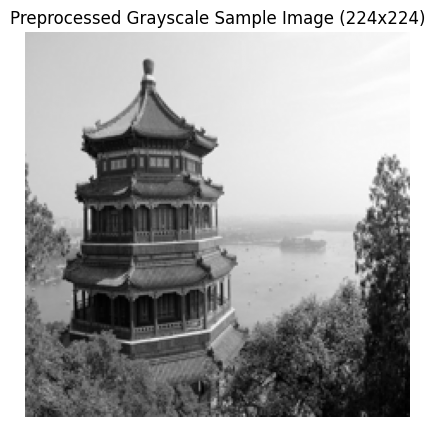

In [9]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_sample_image

try:
    # Python ki built-in sample image load kar rahe hain (Network download ki zarurat nahi)
    china = load_sample_image("china.jpg")

    # PIL image me convert karke Grayscale ('L') bana rahe hain
    img = Image.fromarray(china).convert('L')

    # Lab requirement ke hisab se Preprocessing: 224x224 Resize aur [0, 1] Normalization
    img_resized = img.resize((224, 224))
    img_array = np.array(img_resized) / 255.0  # Pixel Normalization

    print("Original Image Format/Size:", img.size)
    print("Preprocessed Tensor Shape:", img_array.shape)
    print("Pixel Range: Min =", img_array.min(), "Max =", img_array.max())

    # Image Display
    plt.figure(figsize=(5, 5))
    plt.imshow(img_array, cmap='gray')
    plt.title("Preprocessed Grayscale Sample Image (224x224)")
    plt.axis('off')
    plt.show()

except Exception as e:
    print("Error:", e)